In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
topology_path = "resnet_epoch1_layerwise_topology.csv"

results_df = pd.read_csv(topology_path)

print(results_df)

   Block  Relative_Depth  H0_Descriptor  H1_Descriptor      Beta        R2  \
0      1             0.1     341.806491      16.119293  0.806206  0.997987   
1      2             0.2     498.197143      30.079620  0.801277  0.997994   
2      3             0.3     659.780214      46.413650  0.790878  0.996285   
3      4             0.4     771.639885      50.131021  0.785633  0.996279   
4      5             0.5     900.131325      62.157534  0.771107  0.996557   
5      6             0.6    1020.918543      71.173093  0.769210  0.996683   
6      7             0.7    1143.309399      79.656041  0.764712  0.997087   
7      8             0.8    1265.529693      83.540135  0.769779  0.997421   
8      9             0.9    1354.573822      84.172423  0.771726  0.997780   
9     10             1.0    1411.660249      84.444854  0.772153  0.997906   

      PHdim  
0  5.160108  
1  5.032132  
2  4.781891  
3  4.664893  
4  4.368858  
5  4.332940  
6  4.250103  
7  4.343648  
8  4.380707  
9

In [5]:
train_accuracy = 25.36
test_accuracy = 23.50

print("Training accuracy:", train_accuracy, "%")
print("Test accuracy:", test_accuracy, "%")

Training accuracy: 25.36 %
Test accuracy: 23.5 %


In [7]:
generalization_gap = train_accuracy - test_accuracy

print("Generalization gap:", generalization_gap, "percentage points")

Generalization gap: 1.8599999999999994 percentage points


In [9]:
final_block = results_df.iloc[-1]

final_h0 = final_block["H0_Descriptor"]
final_h1 = final_block["H1_Descriptor"]
final_phdim = final_block["PHdim"]

print("Final block:", int(final_block["Block"]))
print("H0 descriptor:", final_h0)
print("H1 descriptor:", final_h1)
print("PHdim:", final_phdim)

Final block: 10
H0 descriptor: 1411.6602493524551
H1 descriptor: 84.44485354423523
PHdim: 4.388906301243683


In [11]:
performance_summary = pd.DataFrame({
    "Model": ["ResNet Epoch 1"],
    "Train_Accuracy": [train_accuracy],
    "Test_Accuracy": [test_accuracy],
    "Generalization_Gap": [generalization_gap],
    "Final_H0": [final_h0],
    "Final_H1": [final_h1],
    "Final_PHdim": [final_phdim]
})

print(performance_summary.to_string(index=False))

         Model  Train_Accuracy  Test_Accuracy  Generalization_Gap    Final_H0  Final_H1  Final_PHdim
ResNet Epoch 1           25.36           23.5                1.86 1411.660249 84.444854     4.388906


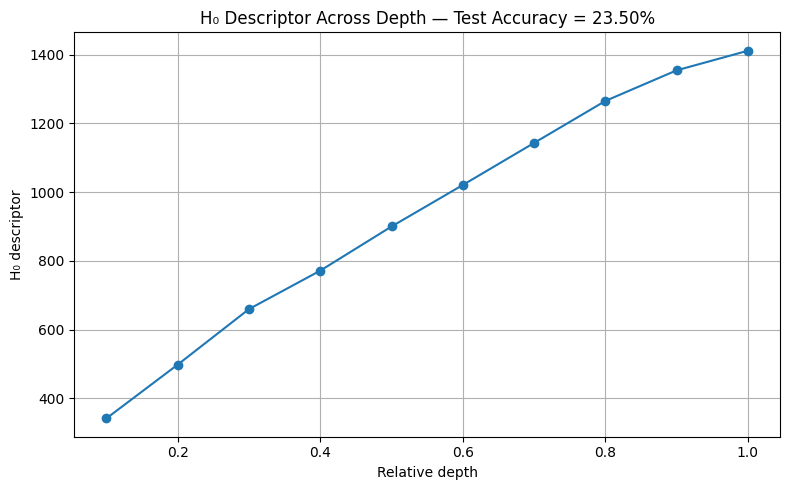

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Relative_Depth"],
    results_df["H0_Descriptor"],
    marker="o"
)

plt.xlabel("Relative depth")
plt.ylabel("H₀ descriptor")
plt.title(
    f"H₀ Descriptor Across Depth — "
    f"Test Accuracy = {test_accuracy:.2f}%"
)

plt.grid(True)
plt.tight_layout()
plt.show()

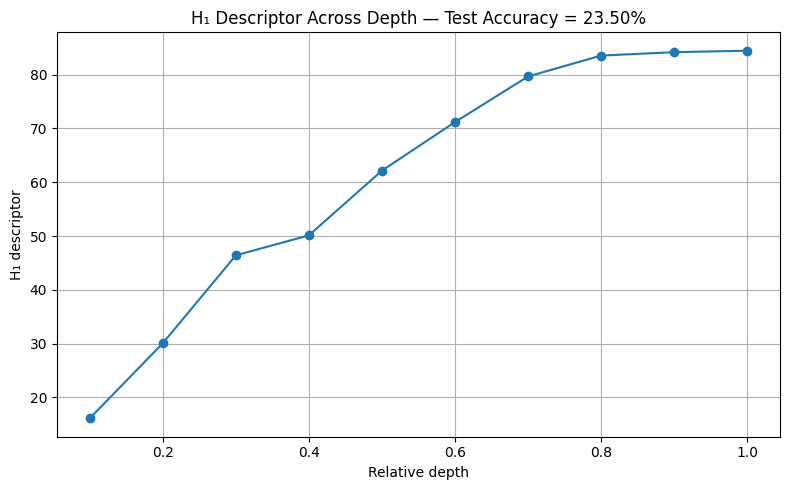

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Relative_Depth"],
    results_df["H1_Descriptor"],
    marker="o"
)

plt.xlabel("Relative depth")
plt.ylabel("H₁ descriptor")
plt.title(
    f"H₁ Descriptor Across Depth — "
    f"Test Accuracy = {test_accuracy:.2f}%"
)

plt.grid(True)
plt.tight_layout()
plt.show()

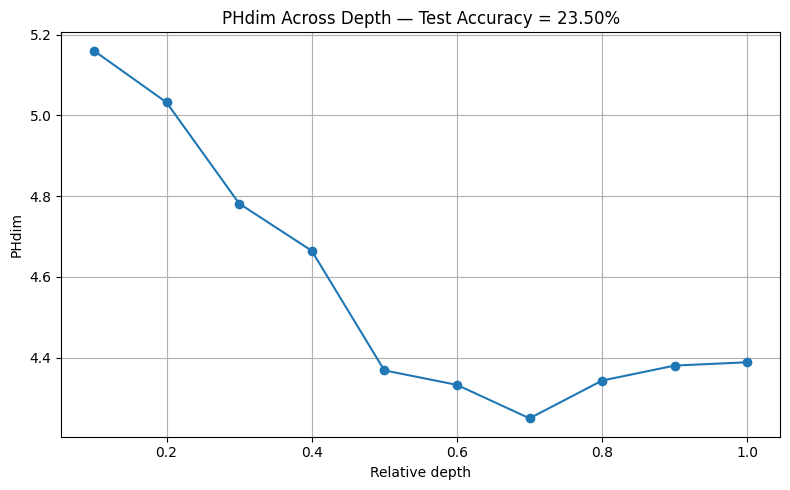

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Relative_Depth"],
    results_df["PHdim"],
    marker="o"
)

plt.xlabel("Relative depth")
plt.ylabel("PHdim")
plt.title(
    f"PHdim Across Depth — "
    f"Test Accuracy = {test_accuracy:.2f}%"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
h0_change = (
    (results_df["H0_Descriptor"].iloc[-1]
     - results_df["H0_Descriptor"].iloc[0])
    / results_df["H0_Descriptor"].iloc[0]
) * 100

h1_change = (
    (results_df["H1_Descriptor"].iloc[-1]
     - results_df["H1_Descriptor"].iloc[0])
    / results_df["H1_Descriptor"].iloc[0]
) * 100

phdim_change = (
    (results_df["PHdim"].iloc[-1]
     - results_df["PHdim"].iloc[0])
    / results_df["PHdim"].iloc[0]
) * 100

print(f"H0 change:    {h0_change:.2f}%")
print(f"H1 change:    {h1_change:.2f}%")
print(f"PHdim change: {phdim_change:.2f}%")

H0 change:    313.00%
H1 change:    423.87%
PHdim change: -14.95%


In [21]:
num_models = 1

print("Number of model/training-state observations:", num_models)

if num_models < 2:
    print(
        "Pearson correlation between topology and accuracy "
        "cannot be meaningfully estimated from the current experiment."
    )

Number of model/training-state observations: 1
Pearson correlation between topology and accuracy cannot be meaningfully estimated from the current experiment.


In [23]:
performance_summary.to_csv(
    "resnet_epoch1_accuracy_topology_summary.csv",
    index=False
)

print(
    "Saved: "
    "resnet_epoch1_accuracy_topology_summary.csv"
)

Saved: resnet_epoch1_accuracy_topology_summary.csv
